# **AirBnB Listings Dataset**



### Overview

This notebook explores the **NYC Airbnb Open Data** dataset, covering listing 
details such as price, location, room type, availability, and review activity.

The goal is to understand what factors influence listing price and how listings 
vary across neighbourhoods and room types.

### What This Notebook Covers

- **Dataset Overview** — shape, structure, and statistical summary of the raw data
- **Data Cleaning** — handling missing values, duplicates, and type inconsistencies
- **Data Analysis** — univariate distributions (price, availability) and outlier removal
- **Bivariate & Multivariate Analysis** — relationships between price, room type, 
  neighbourhood, reviews, and other features, including a correlation check across 
  numeric columns

### Key Question

*What drives price differences across listings in NYC Airbnb data?*

**Importing Dependencies** and **Loading Data-set**

In [75]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv("AirBnB_Listings_NewYork.csv")
print("Dataset has been loaded successfully!")

Dataset has been loaded successfully!


In [ ]:
df.head() 

,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,...,last_review,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,license,rating,bedrooms,beds,baths
0,1.312228e+06,Rental unit in Brooklyn · ★5.0 · 1 bedroom,7130382,Walter,Brooklyn,Clinton Hill,40.683710,-73.964610,Private room,55.0,...,20/12/15,0.03,1.0,0.0,0.0,No License,5,1,1,Not specified
1,4.527754e+07,Rental unit in New York · ★4.67 · 2 bedrooms ·...,51501835,Jeniffer,Manhattan,Hell's Kitchen,40.766610,-73.988100,Entire home/apt,144.0,...,01/05/23,0.24,139.0,364.0,2.0,No License,4.67,2,1,1
2,9.710000e+17,Rental unit in New York · ★4.17 · 1 bedroom · ...,528871354,Joshua,Manhattan,Chelsea,40.750764,-73.994605,Entire home/apt,187.0,...,18/12/23,1.67,1.0,343.0,6.0,Exempt,4.17,1,2,1
3,3.857863e+06,Rental unit in New York · ★4.64 · 1 bedroom · ...,19902271,John And Catherine,Manhattan,Washington Heights,40.835600,-73.942500,Private room,120.0,...,17/09/23,1.38,2.0,363.0,12.0,No License,4.64,1,1,1
4,4.089661e+07,Condo in New York · ★4.91 · Studio · 1 bed · 1...,61391963,Stay With Vibe,Manhattan,Murray Hill,40.751120,-73.978600,Entire home/apt,85.0,...,03/12/23,0.24,133.0,335.0,3.0,No License,4.91,Studio,1,1


## **Data-set Overview**

*Shape* and *Info* about the Data-set

In [77]:
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.info()

Rows: 20770, Columns: 22
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20770 entries, 0 to 20769
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              20770 non-null  float64
 1   name                            20770 non-null  object 
 2   host_id                         20770 non-null  int64  
 3   host_name                       20770 non-null  object 
 4   neighbourhood_group             20770 non-null  object 
 5   neighbourhood                   20763 non-null  object 
 6   latitude                        20763 non-null  float64
 7   longitude                       20763 non-null  float64
 8   room_type                       20763 non-null  object 
 9   price                           20736 non-null  float64
 10  minimum_nights                  20763 non-null  float64
 11  number_of_reviews               20763 non-null  float64
 12  last_re

*Statistical Summary*

In [79]:
df.describe().T # T stands for Transpose.

,count,mean,std,min,25%,50%,75%,max
id,20770.0,3.033858e+17,3.901221e+17,2595.000000,2.707260e+07,4.992852e+07,7.220000e+17,1.050000e+18
host_id,20770.0,1.749049e+08,1.725657e+08,1678.000000,2.041184e+07,1.086990e+08,3.143997e+08,5.504035e+08
latitude,20763.0,4.072682e+01,6.029301e-02,40.500314,4.068416e+01,4.072289e+01,4.076311e+01,4.091115e+01
longitude,20763.0,-7.393918e+01,6.140254e-02,-74.249840,-7.398076e+01,-7.394960e+01,-7.391747e+01,-7.371365e+01
price,20736.0,1.877149e+02,1.023245e+03,10.000000,8.000000e+01,1.250000e+02,1.990000e+02,1.000000e+05
minimum_nights,20763.0,2.855849e+01,3.353270e+01,1.000000,3.000000e+01,3.000000e+01,3.000000e+01,1.250000e+03
number_of_reviews,20763.0,4.261061e+01,7.352340e+01,1.000000,4.000000e+00,1.400000e+01,4.900000e+01,1.865000e+03
reviews_per_month,20763.0,1.257589e+00,1.904472e+00,0.010000,2.100000e-01,6.500000e-01,1.800000e+00,7.549000e+01
calculated_host_listings_count,20763.0,1.886669e+01,7.092144e+01,1.000000,1.000000e+00,2.000000e+00,5.000000e+00,7.130000e+02
availability_365,20763.0,2.060680e+02,1.350773e+02,0.000000,8.700000e+01,2.150000e+02,3.530000e+02,3.650000e+02


## **Data Cleaning**

*Handling the Missing Values in our Dataset*

In [80]:
# Missing values: check, drop, confirm
print("Missing values before:\n", df.isnull().sum())

df.dropna(inplace=True)  # could use fillna() instead if you want to preserve rows

print("\nMissing values after:\n", df.isnull().sum())
print(f"\nShape after dropping nulls: {df.shape}")

Missing values before:
 id                                 0
name                               0
host_id                            0
host_name                          0
neighbourhood_group                0
neighbourhood                      7
latitude                           7
longitude                          7
room_type                          7
price                             34
minimum_nights                     7
number_of_reviews                  7
last_review                        7
reviews_per_month                  7
calculated_host_listings_count     7
availability_365                   7
number_of_reviews_ltm              7
license                            0
rating                             0
bedrooms                           0
beds                               0
baths                              0
dtype: int64

Missing values after:
 id                                0
name                              0
host_id                           0
host_name        

*Dealing with Duplicates in our Dataset*

In [81]:
# Duplicates: check, drop, confirm
print(f"Duplicate rows before: {df.duplicated().sum()}")

df.drop_duplicates(inplace=True)

print(f"Duplicate rows after: {df.duplicated().sum()}")

Duplicate rows before: 12
Duplicate rows after: 0


*Typecasting unecessary information in our Dataset*

In [82]:
# id and host_id are numeric but not meant for math — cast to object
df["id"] = df["id"].astype(object)
df["host_id"] = df["host_id"].astype(object)

print(df.dtypes)

id                                 object
name                               object
host_id                            object
host_name                          object
neighbourhood_group                object
neighbourhood                      object
latitude                          float64
longitude                         float64
room_type                          object
price                             float64
minimum_nights                    float64
number_of_reviews                 float64
last_review                        object
reviews_per_month                 float64
calculated_host_listings_count    float64
availability_365                  float64
number_of_reviews_ltm             float64
license                            object
rating                             object
bedrooms                           object
beds                                int64
baths                              object
dtype: object


## **Data Analysis**

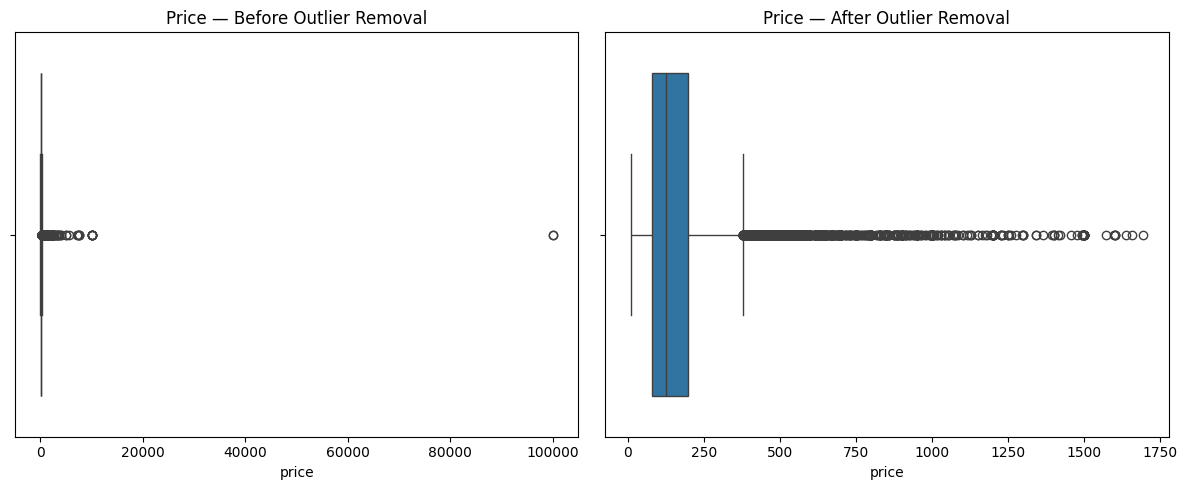

In [83]:
# Outlier check: price has extreme values (>$100k) that distort visualization
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.boxplot(data=df, x='price', ax=axes[0])
axes[0].set_title("Price — Before Outlier Removal")

df_new = df[df['price'] < 1700]  # visual inspection showed bulk of listings under this range
sns.boxplot(data=df_new, x='price', ax=axes[1])
axes[1].set_title("Price — After Outlier Removal")

plt.tight_layout()
plt.show()

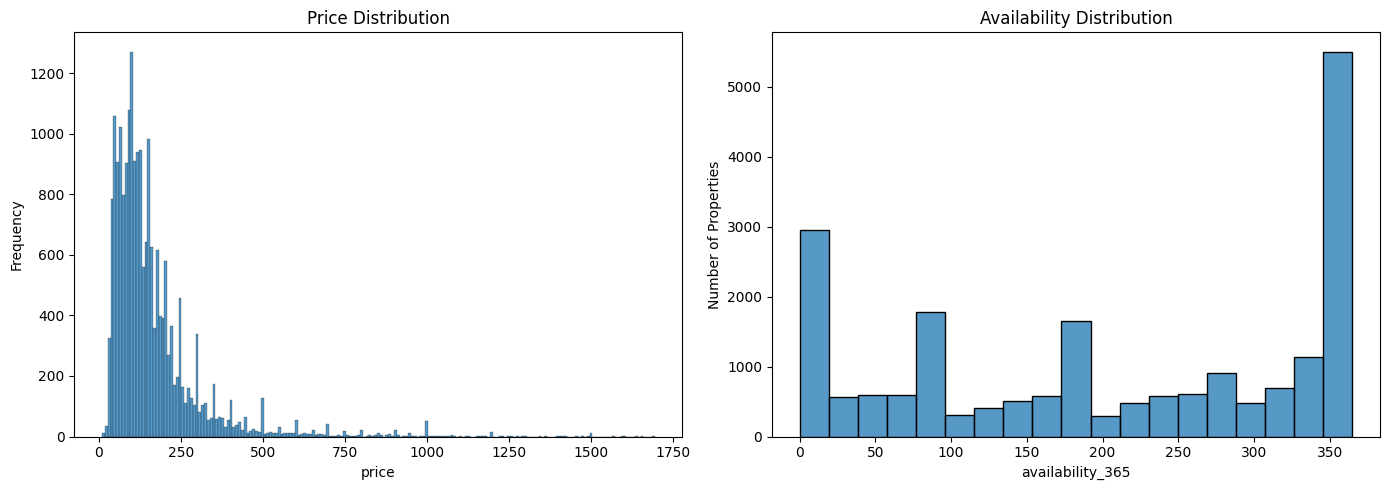

In [84]:
# Univariate analysis: distribution of price and availability
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=df_new, x='price', ax=axes[0])
axes[0].set_title("Price Distribution")
axes[0].set_ylabel("Frequency")

sns.histplot(data=df_new, x='availability_365', ax=axes[1])
axes[1].set_title("Availability Distribution")
axes[1].set_ylabel("Number of Properties")

plt.tight_layout()
plt.show()

### **Group By**

*Grouping by the Average Price per Neighbourhood*

In [ ]:
avg_price_by_area = df_new.groupby("neighbourhood_group")["price"].mean().sort_values(ascending=False)
print(avg_price_by_area.round(2))


neighbourhood_group
Manhattan        206.36
Brooklyn         155.68
Queens           121.68
Staten Island    118.78
Bronx            107.99
Name: price, dtype: float64


In [86]:
print(f"Zero-bed listings: {(df_new['beds'] == 0).sum()}")
df_new['price_per_bed'] = df_new['price'] / df_new['beds'].replace(0, np.nan)

Zero-bed listings: 0


C:\Users\Muhammad Saad Ullah\AppData\Local\Temp\ipykernel_19336\1882850232.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_new['price_per_bed'] = df_new['price'] / df_new['beds'].replace(0, np.nan)


### **Bivariate Analysis**

*Tells the Relation between one column with the other*

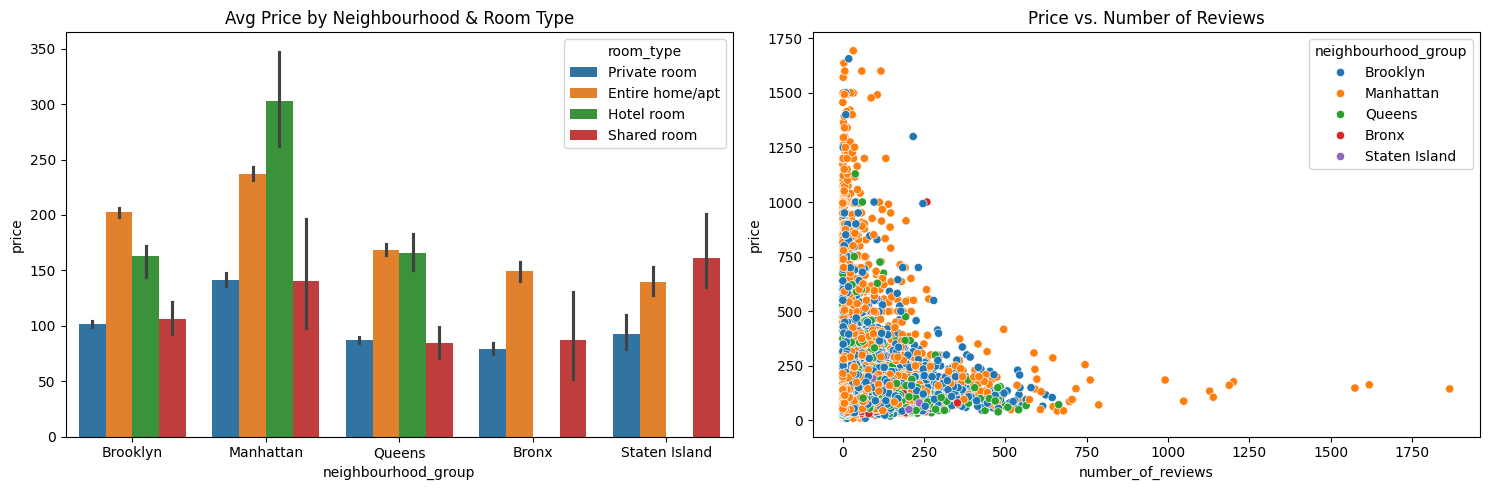

In [87]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.barplot(data=df_new, x="neighbourhood_group", y="price", hue="room_type", ax=axes[0])
axes[0].set_title("Avg Price by Neighbourhood & Room Type")

sns.scatterplot(data=df_new, x="number_of_reviews", y="price", hue="neighbourhood_group", ax=axes[1])
axes[1].set_title("Price vs. Number of Reviews")

plt.tight_layout()
plt.show()

Text(0.5, 1.02, 'Pairwise Relationships by Room Type')

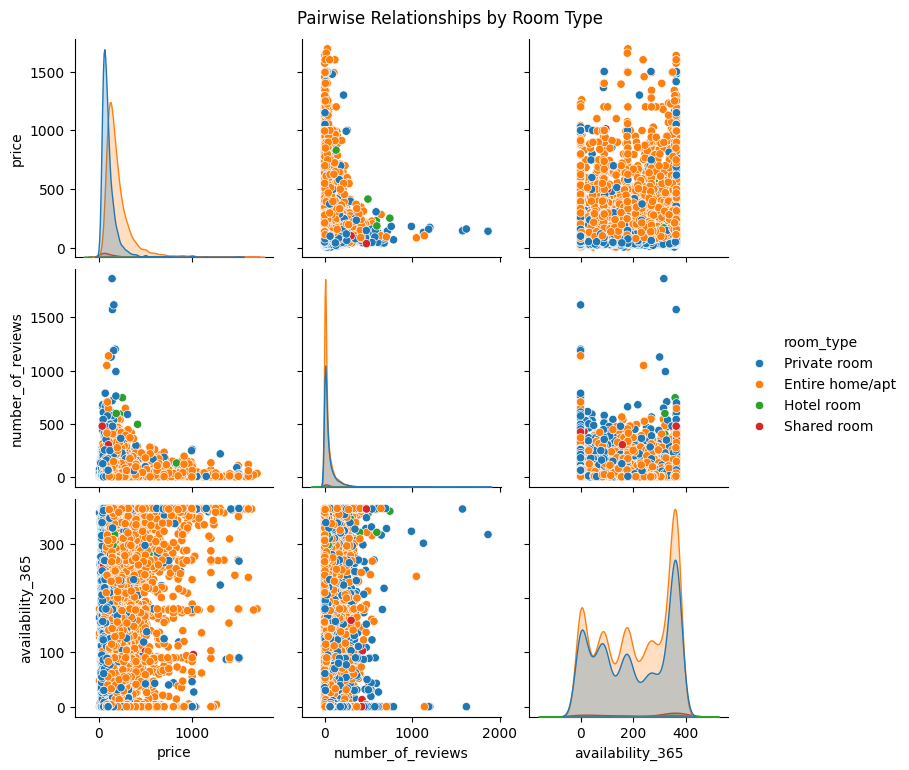

In [88]:
g = sns.pairplot(data=df_new, vars=['price', 'number_of_reviews', 'availability_365'], hue='room_type')
g.fig.suptitle("Pairwise Relationships by Room Type", y=1.02)

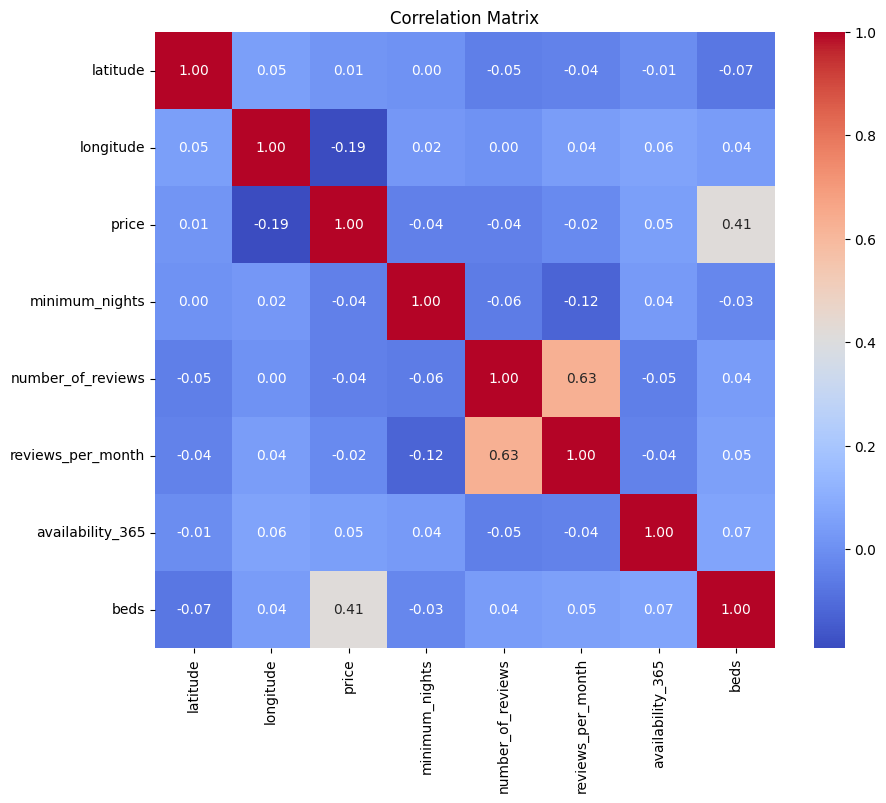

In [89]:
corr = df_new[['latitude', 'longitude', 'price', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'availability_365', 'beds']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(data=corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()